# Baseline de Deteccion de Clones en Python

## Flujo general
- Cargamos y limpiamos metadata
- Reconstruimos pares de snippets
- Preprocesamos codigo y tokenizamos
- Extraemos features lexicas
- Entrenamos y evaluamos Task A y Task B

In [1]:
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Iterable
import io
import random
import re
import tokenize

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import sparse
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.tree import DecisionTreeClassifier


Configuracion global del baseline

In [2]:
# configuracion general
SEED = 42
ESTRATEGIA_BALANCEO = 'none'  # opciones: none, undersample, oversample

random.seed(SEED)
np.random.seed(SEED)

RUTA_BASE = Path.cwd()
if (RUTA_BASE / 'clone_pairs_dataset_metadata.csv').exists():
    RUTA_DATASET = RUTA_BASE
else:
    RUTA_DATASET = RUTA_BASE / 'DataBaseProject'

RUTA_METADATA = RUTA_DATASET / 'clone_pairs_dataset_metadata.csv'

print('RUTA_DATASET:', RUTA_DATASET)
print('RUTA_METADATA:', RUTA_METADATA)
print('ESTRATEGIA_BALANCEO:', ESTRATEGIA_BALANCEO)



RUTA_DATASET: c:\Users\estef\Downloads\code-clone-detector\DataBaseProject\DataBaseProject
RUTA_METADATA: c:\Users\estef\Downloads\code-clone-detector\DataBaseProject\DataBaseProject\clone_pairs_dataset_metadata.csv
ESTRATEGIA_BALANCEO: none


Constantes globales y estructuras auxiliares.

In [3]:
# aqui definimos constantes compartidas.
# tambien dejamos la estructura del split.
COLUMNAS_METADATA = [
    'is_clone',
    'clone_type',
    'source_group',
    'filename',
    'file_path',
    'problem_id',
    'snippet_index_a',
    'snippet_index_b',
]

PATRON_MARCADOR_LENGUAJE = re.compile(
    r'^\s*(python|java|javascript|c\+\+|cpp|ruby|go)\s*$',
    flags=re.IGNORECASE | re.MULTILINE,
)
PATRON_SEPARADOR_SNIPPETS = re.compile(r'\n\s*\n\s*\n+')
PATRON_ESPACIOS = re.compile(r'[ \t]+')
PATRON_SALTOS = re.compile(r'\n{3,}')


@dataclass
class ResultadoSplit:
    # aqui guardamos los indices de cada subconjunto.
    train_idx: pd.Index
    val_idx: pd.Index
    test_idx: pd.Index


### Metadata

Funciones para cargar, validar y limpiar la metadata base del dataset.

In [4]:
def cargar_metadata(ruta_csv: Path) -> pd.DataFrame:
    return pd.read_csv(ruta_csv)


def limpiar_metadata(df: pd.DataFrame) -> pd.DataFrame:
    limpio = df.copy()

    limpio['is_clone'] = pd.to_numeric(limpio['is_clone'], errors='coerce')
    limpio['problem_id'] = pd.to_numeric(limpio['problem_id'], errors='coerce')
    limpio['snippet_index_a'] = pd.to_numeric(limpio['snippet_index_a'], errors='coerce')
    limpio['snippet_index_b'] = pd.to_numeric(limpio['snippet_index_b'], errors='coerce')

    limpio = limpio.dropna(
        subset=['is_clone', 'problem_id', 'snippet_index_a', 'snippet_index_b', 'file_path', 'filename']
    ).copy()

    limpio['is_clone'] = limpio['is_clone'].astype(int)
    limpio['problem_id'] = limpio['problem_id'].astype(int)
    limpio['snippet_index_a'] = limpio['snippet_index_a'].astype(int)
    limpio['snippet_index_b'] = limpio['snippet_index_b'].astype(int)

    return limpio



### Split y balanceo

Funciones para separar por grupo, resumir distribuciones y balancear el train.

In [5]:
def split_por_grupo(
    df: pd.DataFrame,
    group_col: str,
    target_col: str,
    seed: int = 42,
    train_size: float = 0.7,
    val_size: float = 0.15,
    test_size: float = 0.15,
) -> ResultadoSplit:
    proporcion_temp = val_size + test_size
    proporcion_test_rel = test_size / proporcion_temp

    gss_train = GroupShuffleSplit(n_splits=1, train_size=train_size, random_state=seed)
    idx_train_np, idx_temp_np = next(gss_train.split(df, y=df[target_col], groups=df[group_col]))

    df_temp = df.iloc[idx_temp_np]
    gss_temp = GroupShuffleSplit(n_splits=1, test_size=proporcion_test_rel, random_state=seed)
    idx_val_rel, idx_test_rel = next(gss_temp.split(df_temp, y=df_temp[target_col], groups=df_temp[group_col]))

    return ResultadoSplit(
        train_idx=df.index[idx_train_np],
        val_idx=df_temp.index[idx_val_rel],
        test_idx=df_temp.index[idx_test_rel],
    )


def estadisticas_split(df: pd.DataFrame, split_col: str, target_col: str, group_col: str) -> list[dict[str, Any]]:
    resumen = []
    for nombre_split, df_split in df.groupby(split_col):
        conteos = df_split[target_col].value_counts().to_dict()
        resumen.append(
            {
                'split': nombre_split,
                'rows': int(len(df_split)),
                'unique_groups': int(df_split[group_col].nunique()),
                'class_distribution': {str(k): int(v) for k, v in conteos.items()},
            }
        )
    return resumen


def balancear_train(
    df_train: pd.DataFrame,
    target_col: str,
    estrategia: str = 'none',
    seed: int = 42,
) -> tuple[pd.DataFrame, dict[str, Any]]:
    conteos_originales = df_train[target_col].value_counts()
    info = {
        'strategy': estrategia,
        'target_col': target_col,
        'rows_before': int(len(df_train)),
        'class_distribution_before': {str(k): int(v) for k, v in conteos_originales.items()},
    }

    if estrategia == 'none' or len(conteos_originales) <= 1:
        info['rows_after'] = int(len(df_train))
        info['class_distribution_after'] = info['class_distribution_before']
        return df_train.copy(), info

    if estrategia == 'undersample':
        tam_objetivo = int(conteos_originales.min())
        reemplazo = False
    elif estrategia == 'oversample':
        tam_objetivo = int(conteos_originales.max())
        reemplazo = True
    else:
        info['rows_after'] = int(len(df_train))
        info['class_distribution_after'] = info['class_distribution_before']
        return df_train.copy(), info

    partes = []
    for clase in conteos_originales.index.tolist():
        df_clase = df_train[df_train[target_col] == clase]
        partes.append(df_clase.sample(n=tam_objetivo, replace=reemplazo, random_state=seed))

    df_balanceado = pd.concat(partes, axis=0).sample(frac=1.0, random_state=seed).copy()
    conteos_balanceados = df_balanceado[target_col].value_counts()

    info['rows_after'] = int(len(df_balanceado))
    info['class_distribution_after'] = {str(k): int(v) for k, v in conteos_balanceados.items()}
    return df_balanceado, info


def ratio_desbalance(series: pd.Series) -> float:
    conteos = series.value_counts()
    if conteos.empty:
        return 1.0
    if len(conteos) == 1:
        return float('inf')
    return float(conteos.max() / conteos.min())


def asignar_split(df, idx_train, idx_val, idx_test, nombre_columna='split'):
    datos = df.copy()
    datos[nombre_columna] = 'unassigned'
    datos.loc[idx_train, nombre_columna] = 'train'
    datos.loc[idx_val, nombre_columna] = 'val'
    datos.loc[idx_test, nombre_columna] = 'test'
    return datos



### Reconstruccion de snippets

Funciones para leer archivos, segmentar snippets y reconstruir `code_a` y `code_b`.


In [6]:
def separar_snippets(texto_archivo: str) -> list[str]:
    texto = texto_archivo.replace('\r\n', '\n').replace('\r', '\n').strip()
    if not texto:
        return []

    bloques = [b.strip() for b in PATRON_MARCADOR_LENGUAJE.split(texto) if b.strip()]
    snippets: list[str] = []

    for bloque in bloques:
        partes = [p.strip() for p in PATRON_SEPARADOR_SNIPPETS.split(bloque) if p.strip()]
        if len(partes) > 1:
            snippets.extend(partes)
        else:
            snippets.append(bloque)

    if len(snippets) < 2:
        partes_fallback = [p.strip() for p in PATRON_SEPARADOR_SNIPPETS.split(texto) if p.strip()]
        if len(partes_fallback) > len(snippets):
            snippets = partes_fallback

    return snippets


def normalizar_ruta_relativa(ruta: str) -> Path:
    return Path(str(ruta).replace('\\', '/'))


def reconstruir_pares(df_metadata: pd.DataFrame, ruta_dataset: Path) -> tuple[pd.DataFrame, pd.DataFrame, dict[str, Any]]:
    filas_ok: list[dict[str, Any]] = []
    filas_drop: list[dict[str, Any]] = []
    cache_snippets: dict[str, list[str]] = {}

    for fila in df_metadata.itertuples(index=False):
        ruta_rel = normalizar_ruta_relativa(str(fila.file_path))
        ruta_abs = ruta_dataset / ruta_rel

        clave = str(ruta_rel).lower()
        if clave not in cache_snippets:
            texto = ruta_abs.read_text(encoding='utf-8', errors='replace')
            cache_snippets[clave] = separar_snippets(texto)

        snippets = cache_snippets[clave]
        idx_a = int(fila.snippet_index_a)
        idx_b = int(fila.snippet_index_b)

        if idx_a == idx_b:
            filas_drop.append({**fila._asdict(), 'drop_reason': 'identical_snippet_indices'})
            continue
        if idx_a < 0 or idx_b < 0:
            filas_drop.append({**fila._asdict(), 'drop_reason': 'negative_snippet_index'})
            continue
        if idx_a >= len(snippets) or idx_b >= len(snippets):
            filas_drop.append({**fila._asdict(), 'drop_reason': 'snippet_index_out_of_range'})
            continue

        filas_ok.append(
            {
                **fila._asdict(),
                'resolved_path': str(ruta_abs),
                'snippet_count': len(snippets),
                'code_a': snippets[idx_a],
                'code_b': snippets[idx_b],
            }
        )

    df_ok = pd.DataFrame(filas_ok)
    df_drop = pd.DataFrame(filas_drop)
    resumen = {
        'metadata_rows': int(len(df_metadata)),
        'reconstructed_rows': int(len(df_ok)),
        'dropped_rows': int(len(df_drop)),
    }
    return df_ok, df_drop, resumen



### Preprocesamiento y tokenizacion

Funciones para limpiar codigo, remover comentarios y tokenizar snippets Python.

In [7]:
def quitar_comentarios(codigo: str) -> str:
    # aqui removemos comentarios para bajar ruido.
    if not codigo.strip():
        return codigo
    try:
        salida = []
        lector = io.StringIO(codigo).readline
        for tok in tokenize.generate_tokens(lector):
            if tok.type == tokenize.COMMENT:
                continue
            salida.append(tok)
        return tokenize.untokenize(salida)
    except (tokenize.TokenError, IndentationError):
        return codigo


def normalizar_espacios(codigo: str) -> str:
    # aqui compactamos espacios y saltos.
    lineas = []
    for linea in codigo.splitlines():
        compacta = PATRON_ESPACIOS.sub(' ', linea).rstrip()
        lineas.append(compacta)
    normalizado = '\n'.join(lineas).strip()
    normalizado = PATRON_SALTOS.sub('\n\n', normalizado)
    return normalizado


def preprocesar_codigo(codigo: str) -> str:
    # aqui aplicamos el preprocesamiento minimo.
    return normalizar_espacios(quitar_comentarios(codigo))


def tokenizar_python(codigo: str) -> list[str]:
    # aqui convertimos codigo a tokens.
    if not codigo.strip():
        return []
    try:
        tokens: list[str] = []
        lector = io.StringIO(codigo).readline
        excluir = {
            tokenize.ENCODING,
            tokenize.ENDMARKER,
            tokenize.NL,
            tokenize.NEWLINE,
            tokenize.INDENT,
            tokenize.DEDENT,
            tokenize.COMMENT,
        }
        for tok in tokenize.generate_tokens(lector):
            if tok.type in excluir:
                continue
            texto = tok.string.strip()
            if texto:
                tokens.append(texto)
        return tokens
    except (tokenize.TokenError, IndentationError):
        return re.findall(r'[A-Za-z_]\w*|\d+|==|!=|<=|>=|[-+*/%=<>()[\]{}.,:;]', codigo)


def preparar_campos_par(df: pd.DataFrame) -> pd.DataFrame:
    # aqui preparamos ambos lados del par.
    out = df.copy()
    code_a_clean = [preprocesar_codigo(x) for x in out['code_a'].astype(str)]
    code_b_clean = [preprocesar_codigo(x) for x in out['code_b'].astype(str)]

    tokens_a = [tokenizar_python(x) for x in code_a_clean]
    tokens_b = [tokenizar_python(x) for x in code_b_clean]

    out['code_a_clean'] = code_a_clean
    out['code_b_clean'] = code_b_clean
    out['tokens_a'] = tokens_a
    out['tokens_b'] = tokens_b
    out['token_text_a'] = [' '.join(t) for t in tokens_a]
    out['token_text_b'] = [' '.join(t) for t in tokens_b]
    return out


### Features lexicas

Funciones para construir similitudes y variables numericas por par de snippets.

In [8]:
def similitud_jaccard(tokens_a: Iterable[str], tokens_b: Iterable[str]) -> float:
    # aqui medimos similitud por conjuntos.
    set_a = set(tokens_a)
    set_b = set(tokens_b)
    if not set_a and not set_b:
        return 1.0
    union = set_a | set_b
    if not union:
        return 0.0
    return float(len(set_a & set_b) / len(union))


def similitud_dice(tokens_a: Iterable[str], tokens_b: Iterable[str]) -> float:
    # aqui calculamos la variante dice.
    set_a = set(tokens_a)
    set_b = set(tokens_b)
    if not set_a and not set_b:
        return 1.0
    denom = len(set_a) + len(set_b)
    if denom == 0:
        return 0.0
    return float(2.0 * len(set_a & set_b) / denom)


def ratio_overlap(tokens_a: Iterable[str], tokens_b: Iterable[str]) -> float:
    # aqui medimos cobertura del menor conjunto.
    set_a = set(tokens_a)
    set_b = set(tokens_b)
    if not set_a and not set_b:
        return 1.0
    min_size = min(len(set_a), len(set_b))
    if min_size == 0:
        return 0.0
    return float(len(set_a & set_b) / min_size)


def ajustar_tfidf(df_train: pd.DataFrame) -> TfidfVectorizer:
    # aqui ajustamos el vector solo con train.
    corpus = pd.concat([df_train['token_text_a'], df_train['token_text_b']], axis=0)
    vector = TfidfVectorizer(
        tokenizer=str.split,
        preprocessor=None,
        token_pattern=None,
        lowercase=False,
        ngram_range=(1, 2),
        min_df=1,
    )
    vector.fit(corpus)
    return vector


def coseno_fila_a_fila(mat_a: sparse.spmatrix, mat_b: sparse.spmatrix) -> np.ndarray:
    # aqui comparamos fila contra fila.
    producto = np.asarray(mat_a.multiply(mat_b).sum(axis=1)).ravel()
    norma_a = np.sqrt(np.asarray(mat_a.multiply(mat_a).sum(axis=1)).ravel())
    norma_b = np.sqrt(np.asarray(mat_b.multiply(mat_b).sum(axis=1)).ravel())
    denom = norma_a * norma_b
    denom[denom == 0.0] = 1e-12
    return producto / denom


def construir_features_par(df: pd.DataFrame, vector: TfidfVectorizer) -> pd.DataFrame:
    # aqui armamos las features finales.
    mat_a = vector.transform(df['token_text_a'])
    mat_b = vector.transform(df['token_text_b'])
    coseno = coseno_fila_a_fila(mat_a, mat_b)

    chars_a = df['code_a_clean'].str.len().astype(float)
    chars_b = df['code_b_clean'].str.len().astype(float)
    lineas_a = df['code_a_clean'].str.count('\n').astype(float) + 1.0
    lineas_b = df['code_b_clean'].str.count('\n').astype(float) + 1.0
    tokens_a = df['tokens_a'].apply(len).astype(float)
    tokens_b = df['tokens_b'].apply(len).astype(float)

    jaccard = [similitud_jaccard(a, b) for a, b in zip(df['tokens_a'], df['tokens_b'])]
    dice = [similitud_dice(a, b) for a, b in zip(df['tokens_a'], df['tokens_b'])]
    overlap = [ratio_overlap(a, b) for a, b in zip(df['tokens_a'], df['tokens_b'])]

    return pd.DataFrame(
        {
            'cosine_tfidf': coseno,
            'jaccard_tokens': jaccard,
            'dice_tokens': dice,
            'overlap_unique_tokens': overlap,
            'char_len_a': chars_a,
            'char_len_b': chars_b,
            'char_len_diff': (chars_a - chars_b).abs(),
            'line_count_a': lineas_a,
            'line_count_b': lineas_b,
            'line_count_diff': (lineas_a - lineas_b).abs(),
            'token_count_a': tokens_a,
            'token_count_b': tokens_b,
            'token_count_diff': (tokens_a - tokens_b).abs(),
        },
        index=df.index,
    )


### Evaluacion y entrenamiento

Funciones para medir rendimiento, graficar resultados y entrenar el baseline.

In [9]:
def evaluar_predicciones(y_true, y_pred, labels: list, y_proba=None) -> dict[str, Any]:
    # aqui calculamos metricas y reportes.
    acc = accuracy_score(y_true, y_pred)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    p_w, r_w, f1_w, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )

    reporte_dict = classification_report(y_true, y_pred, labels=labels, output_dict=True, zero_division=0)
    reporte_texto = classification_report(y_true, y_pred, labels=labels, zero_division=0)
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    roc_auc = None
    if y_proba is not None:
        try:
            proba = np.asarray(y_proba)
            if len(labels) == 2:
                roc_auc = float(roc_auc_score(y_true, proba[:, 1]))
            else:
                roc_auc = float(roc_auc_score(y_true, proba, labels=labels, multi_class='ovr'))
        except (ValueError, IndexError):
            roc_auc = None

    return {
        'accuracy': float(acc),
        'precision_macro': float(p_macro),
        'recall_macro': float(r_macro),
        'f1_macro': float(f1_macro),
        'precision_weighted': float(p_w),
        'recall_weighted': float(r_w),
        'f1_weighted': float(f1_w),
        'confusion_matrix': cm.tolist(),
        'classification_report_dict': reporte_dict,
        'classification_report_text': reporte_texto,
        'roc_auc': roc_auc,
    }


def graficar_balanceo(info_balanceo, titulo):
    # aqui mostramos el antes y despues.
    antes = info_balanceo['class_distribution_before']
    despues = info_balanceo['class_distribution_after']

    clases = sorted(set(list(antes.keys()) + list(despues.keys())))
    valores_antes = [antes.get(c, 0) for c in clases]
    valores_despues = [despues.get(c, 0) for c in clases]

    x = np.arange(len(clases))
    width = 0.35

    plt.figure(figsize=(8, 4))
    plt.bar(x - width / 2, valores_antes, width=width, label='Antes', color='#4C78A8')
    plt.bar(x + width / 2, valores_despues, width=width, label='Despues', color='#E45756')
    plt.xticks(x, clases)
    plt.title(titulo)
    plt.xlabel('Clase')
    plt.ylabel('Cantidad')
    plt.legend()
    plt.tight_layout()
    plt.show()


def entrenar_evaluar_decision_tree(
    datos_task,
    columna_target,
    etiquetas,
    seed,
    estrategia_balanceo='none',
    graficar_roc=False,
):
    # aqui dividimos el task en train, val y test.
    train_raw = datos_task[datos_task['split'] == 'train'].copy()
    val = datos_task[datos_task['split'] == 'val'].copy()
    test = datos_task[datos_task['split'] == 'test'].copy()

    # aqui balanceamos solo train.
    train_balanceado, info_balanceo = balancear_train(
        df_train=train_raw,
        target_col=columna_target,
        estrategia=estrategia_balanceo,
        seed=seed,
    )

    graficar_balanceo(info_balanceo, f'Balanceo train - {columna_target}')

    # aqui decidimos si usar class_weight.
    ratio_desbalance_train = ratio_desbalance(train_balanceado[columna_target])
    peso_clases = 'balanced' if ratio_desbalance_train >= 1.5 else None

    # aqui construimos features para cada split.
    vector_tfidf = ajustar_tfidf(train_balanceado)
    caracteristicas_train = construir_features_par(train_balanceado, vector_tfidf)
    caracteristicas_val = construir_features_par(val, vector_tfidf)
    caracteristicas_test = construir_features_par(test, vector_tfidf)

    # aqui entrenamos el arbol.
    modelo_arbol = DecisionTreeClassifier(
        criterion='gini',
        max_depth=12,
        min_samples_leaf=2,
        class_weight=peso_clases,
        random_state=seed,
    )
    modelo_arbol.fit(caracteristicas_train, train_balanceado[columna_target])

    y_val = val[columna_target]
    y_test = test[columna_target]

    # aqui generamos predicciones y probabilidades.
    pred_val = modelo_arbol.predict(caracteristicas_val)
    pred_test = modelo_arbol.predict(caracteristicas_test)

    proba_val = modelo_arbol.predict_proba(caracteristicas_val)
    proba_test = modelo_arbol.predict_proba(caracteristicas_test)

    metricas_val = evaluar_predicciones(y_val, pred_val, labels=etiquetas, y_proba=proba_val)
    metricas_test = evaluar_predicciones(y_test, pred_test, labels=etiquetas, y_proba=proba_test)

    print('--- Informacion de balanceo ---')
    print(info_balanceo)
    print('Ratio desbalance train despues de balancear:', round(ratio_desbalance_train, 4))
    print('class_weight usado:', peso_clases)

    print('')
    print('--- Metricas VALIDACION ---')
    print('accuracy:', round(metricas_val['accuracy'], 4))
    print('f1_macro:', round(metricas_val['f1_macro'], 4))

    print('')
    print('--- Metricas TEST ---')
    print('accuracy:', round(metricas_test['accuracy'], 4))
    print('precision_macro:', round(metricas_test['precision_macro'], 4))
    print('recall_macro:', round(metricas_test['recall_macro'], 4))
    print('f1_macro:', round(metricas_test['f1_macro'], 4))

    print('')
    print('Reporte de clasificacion TEST:')
    print(metricas_test['classification_report_text'])

    cm_val = np.array(metricas_val['confusion_matrix'])
    cm_test = np.array(metricas_test['confusion_matrix'])

    # aqui graficamos matrices de confusion.
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    ConfusionMatrixDisplay(cm_val, display_labels=[str(x) for x in etiquetas]).plot(ax=axes[0], colorbar=False)
    axes[0].set_title(f'{columna_target} - Matriz VAL')
    ConfusionMatrixDisplay(cm_test, display_labels=[str(x) for x in etiquetas]).plot(ax=axes[1], colorbar=False)
    axes[1].set_title(f'{columna_target} - Matriz TEST')
    plt.tight_layout()
    plt.show()

    if graficar_roc and len(etiquetas) == 2:
        # aqui agregamos curvas roc cuando aplica.
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        RocCurveDisplay.from_predictions(y_val, proba_val[:, 1], pos_label=etiquetas[1], ax=axes[0])
        axes[0].set_title(f'{columna_target} - ROC VAL')
        RocCurveDisplay.from_predictions(y_test, proba_test[:, 1], pos_label=etiquetas[1], ax=axes[1])
        axes[1].set_title(f'{columna_target} - ROC TEST')
        plt.tight_layout()
        plt.show()

    return {
        'info_balanceo': info_balanceo,
        'metricas_val': metricas_val,
        'metricas_test': metricas_test,
        'modelo': modelo_arbol,
    }


### Carga, validacion y limpieza de metadata


In [10]:
# carga de metadata
datos_metadata = cargar_metadata(RUTA_METADATA)
datos_metadata_limpios = limpiar_metadata(datos_metadata)

print('Filas metadata:', len(datos_metadata))
print('Filas validas:', len(datos_metadata_limpios))


datos_metadata_limpios.head(3)



FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\estef\\Downloads\\code-clone-detector\\DataBaseProject\\DataBaseProject\\clone_pairs_dataset_metadata.csv'

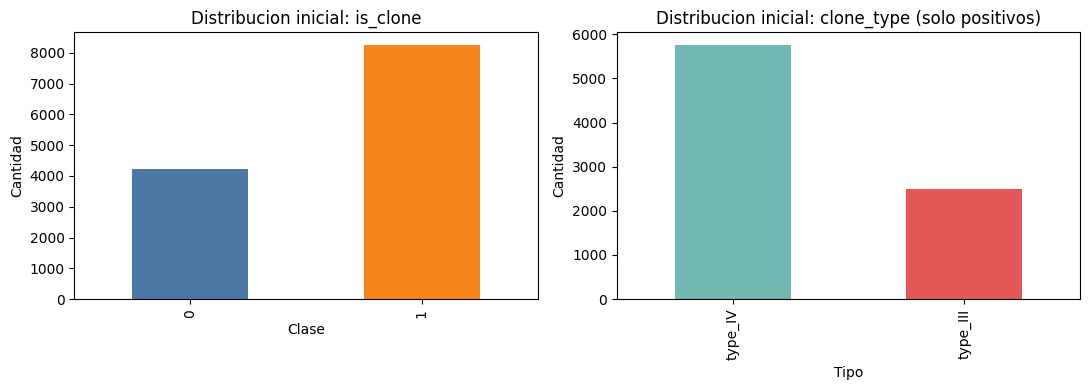

In [ ]:
# aqui vemos la distribucion inicial de clases.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
datos_metadata_limpios['is_clone'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=['#4C78A8', '#F58518']
)
axes[0].set_title('Distribucion inicial: is_clone')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Cantidad')

datos_metadata_limpios[datos_metadata_limpios['is_clone'] == 1]['clone_type'].value_counts().plot(
    kind='bar', ax=axes[1], color=['#72B7B2', '#E45756']
)
axes[1].set_title('Distribucion inicial: clone_type (solo positivos)')
axes[1].set_xlabel('Tipo')
axes[1].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()


### Reconstruccion de pares

In [ ]:
# reconstruccion de pares
datos_reconstruidos, filas_descartadas, resumen_reconstruccion = reconstruir_pares(
    datos_metadata_limpios,
    ruta_dataset=RUTA_DATASET,
)

print('Resumen reconstruccion:')
print(resumen_reconstruccion)



Resumen reconstruccion:
{'metadata_rows': 12484, 'reconstructed_rows': 12484, 'dropped_rows': 0, 'drop_reasons': {}}


,file_path,snippet_index_a,snippet_index_b,is_clone,clone_type
0,true_semantic_clones\py\MT3\Clone_1.py,0,1,1,type_III
1,true_semantic_clones\py\MT3\Clone_2.py,0,1,1,type_III
2,true_semantic_clones\py\MT3\Clone_3.py,0,1,1,type_III
3,true_semantic_clones\py\MT3\Clone_4.py,0,1,1,type_III
4,true_semantic_clones\py\MT3\Clone_5.py,0,1,1,type_III


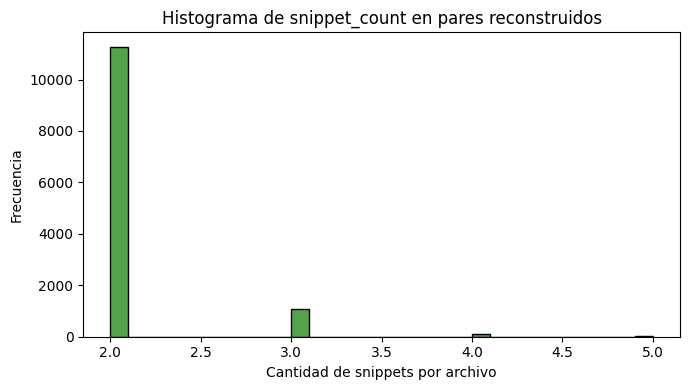

In [ ]:
# aqui inspeccionamos algunos pares.
# tambien vemos cuantos snippets aparecen por archivo.
display(
    datos_reconstruidos[['file_path', 'snippet_index_a', 'snippet_index_b', 'is_clone', 'clone_type']].head(5)
)

plt.figure(figsize=(7, 4))
plt.hist(datos_reconstruidos['snippet_count'], bins=30, color='#54A24B', edgecolor='black')
plt.title('Histograma de snippet_count en pares reconstruidos')
plt.xlabel('Cantidad de snippets por archivo')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()


### Preprocesamiento y tokenizacion


In [ ]:
# aqui aplicamos preprocessing y tokenizacion.
# luego mostramos ejemplos cortos.
datos_preparados = preparar_campos_par(datos_reconstruidos)
print('Filas procesadas:', len(datos_preparados))

display(datos_preparados[['code_a_clean', 'code_b_clean', 'token_text_a', 'token_text_b']].head(2))


Filas procesadas: 12484


,code_a_clean,code_b_clean,token_text_a,token_text_b
0,def second_largest(numbers) :\n count = 0\n m1...,def second_largest(numbers):\n\n if len(number...,def second_largest ( numbers ) : count = 0 m1 ...,def second_largest ( numbers ) : if len ( numb...
1,"def write(self, data) :\n if data [0 : LOG_IDR...","def write(self, data) :\n if data [0 : LOG_IDR...","def write ( self , data ) : if data [ 0 : LOG_...","def write ( self , data ) : if data [ 0 : LOG_..."


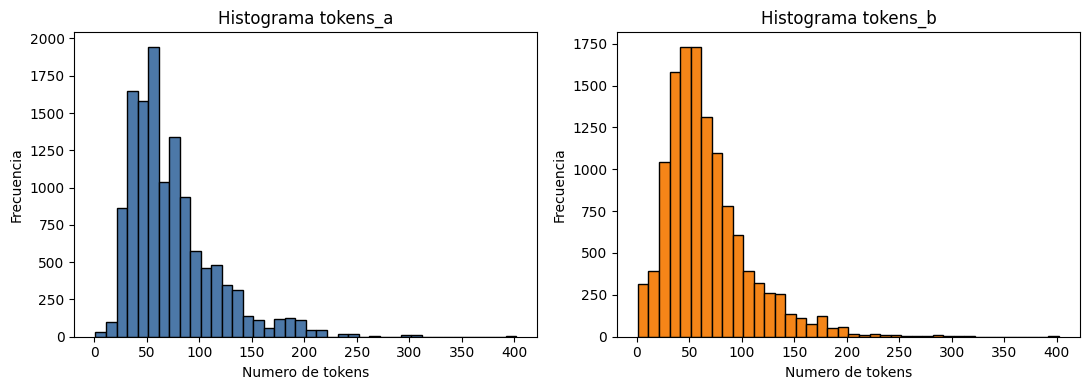

In [ ]:
# aqui revisamos el tamano de los tokens por lado.
long_tokens_a = datos_preparados['tokens_a'].apply(len)
long_tokens_b = datos_preparados['tokens_b'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(long_tokens_a, bins=40, color='#4C78A8', edgecolor='black')
axes[0].set_title('Histograma tokens_a')
axes[0].set_xlabel('Numero de tokens')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(long_tokens_b, bins=40, color='#F58518', edgecolor='black')
axes[1].set_title('Histograma tokens_b')
axes[1].set_xlabel('Numero de tokens')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()


### Task A - `is_clone` (0/1)


In [ ]:
# aqui construimos el split de task a.
# el grupo es problem_id para evitar fuga.
split_task_a = split_por_grupo(
    df=datos_preparados,
    group_col='problem_id',
    target_col='is_clone',
    seed=SEED,
    train_size=0.7,
    val_size=0.15,
    test_size=0.15,
)

datos_task_a = asignar_split(
    datos_preparados,
    idx_train=split_task_a.train_idx,
    idx_val=split_task_a.val_idx,
    idx_test=split_task_a.test_idx,
)

print('Estadisticas split Task A:')
stats_a = estadisticas_split(datos_task_a, 'split', 'is_clone', 'problem_id')
for fila in stats_a:
    print(fila)


Estadisticas split Task A:
{'split': 'test', 'rows': 1859, 'unique_groups': 823, 'class_distribution': {'1': 1230, '0': 629}}
{'split': 'train', 'rows': 8754, 'unique_groups': 3838, 'class_distribution': {'1': 5787, '0': 2967}}
{'split': 'val', 'rows': 1871, 'unique_groups': 823, 'class_distribution': {'1': 1236, '0': 635}}


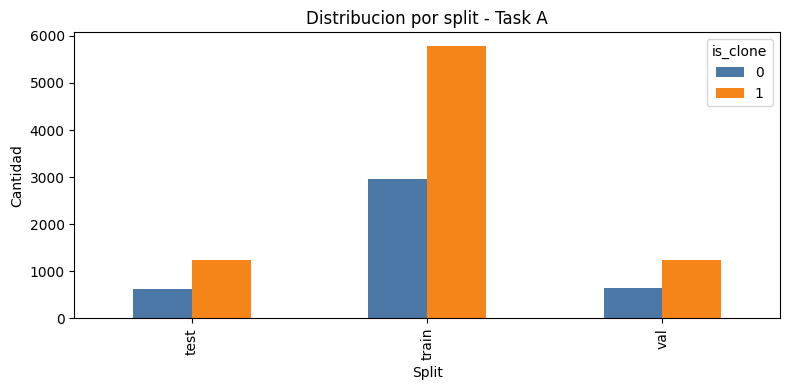

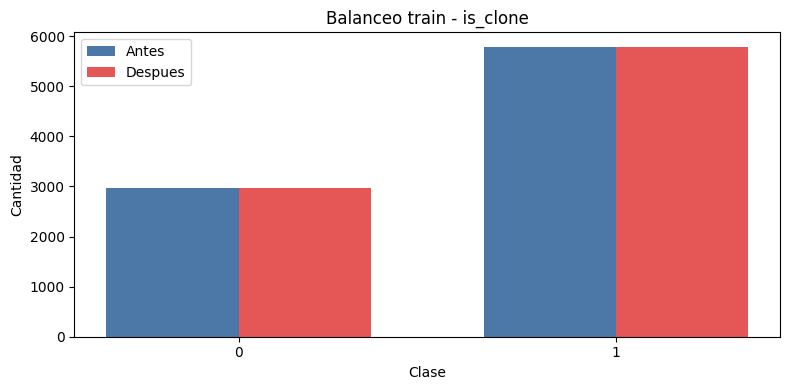

--- Informacion de balanceo ---
{'strategy': 'none', 'target_col': 'is_clone', 'rows_before': 8754, 'class_distribution_before': {'1': 5787, '0': 2967}, 'rows_after': 8754, 'class_distribution_after': {'1': 5787, '0': 2967}}
Ratio desbalance train despues de balancear: 1.9505
class_weight usado: balanced

--- Metricas VALIDACION ---
accuracy: 0.8947
f1_macro: 0.8847

--- Metricas TEST ---
accuracy: 0.8999
precision_macro: 0.8854
recall_macro: 0.8945
f1_macro: 0.8896

Reporte de clasificacion TEST:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       629
           1       0.94      0.91      0.92      1230

    accuracy                           0.90      1859
   macro avg       0.89      0.89      0.89      1859
weighted avg       0.90      0.90      0.90      1859



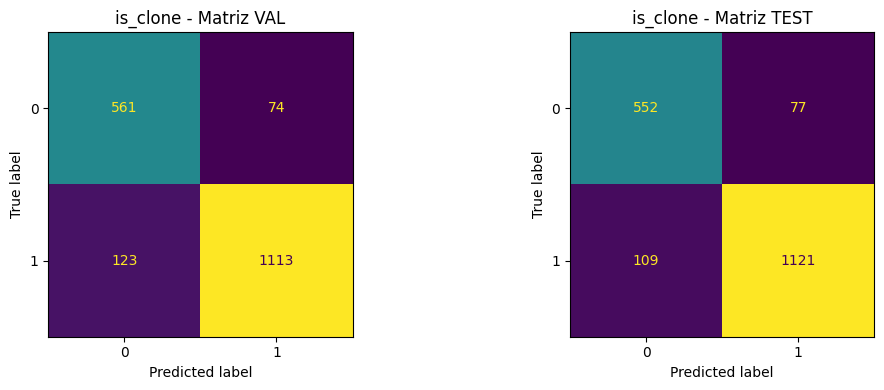

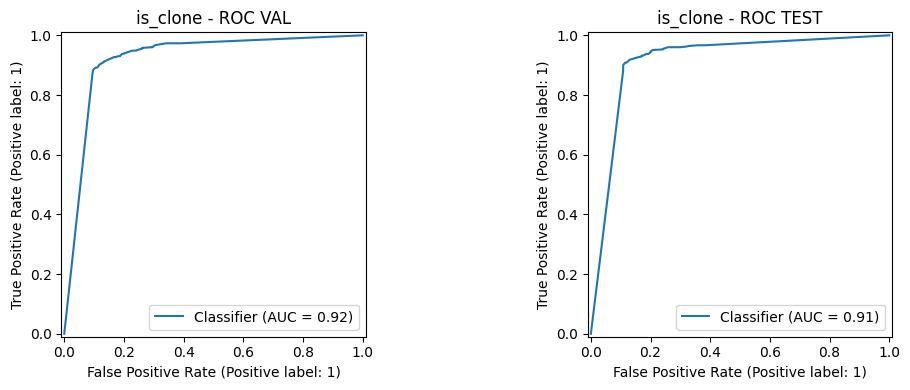

In [ ]:
# aqui graficamos el split y entrenamos task a.
conteos_split_a = datos_task_a.groupby(['split', 'is_clone']).size().unstack(fill_value=0)
conteos_split_a.plot(kind='bar', figsize=(8, 4), color=['#4C78A8', '#F58518'])
plt.title('Distribucion por split - Task A')
plt.xlabel('Split')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()

resultado_task_a = entrenar_evaluar_decision_tree(
    datos_task_a,
    columna_target='is_clone',
    etiquetas=[0, 1],
    seed=SEED,
    estrategia_balanceo=ESTRATEGIA_BALANCEO,
    graficar_roc=True,
)


### Task B - `clone_type`

Se trabaja solo con pares positivos para clasificar el tipo de clon.


In [ ]:
# aqui filtramos solo pares positivos.
# despues construimos el split de task b.
datos_positivos = datos_preparados[datos_preparados['is_clone'] == 1].copy()

split_task_b = split_por_grupo(
    df=datos_positivos,
    group_col='problem_id',
    target_col='clone_type',
    seed=SEED + 100,
    train_size=0.7,
    val_size=0.15,
    test_size=0.15,
)

datos_task_b = asignar_split(
    datos_positivos,
    idx_train=split_task_b.train_idx,
    idx_val=split_task_b.val_idx,
    idx_test=split_task_b.test_idx,
)

print('Estadisticas split Task B:')
stats_b = estadisticas_split(datos_task_b, 'split', 'clone_type', 'problem_id')
for fila in stats_b:
    print(fila)


Estadisticas split Task B:
{'split': 'test', 'rows': 1240, 'unique_groups': 823, 'class_distribution': {'type_IV': 865, 'type_III': 375}}
{'split': 'train', 'rows': 5788, 'unique_groups': 3838, 'class_distribution': {'type_IV': 4037, 'type_III': 1751}}
{'split': 'val', 'rows': 1225, 'unique_groups': 822, 'class_distribution': {'type_IV': 854, 'type_III': 371}}


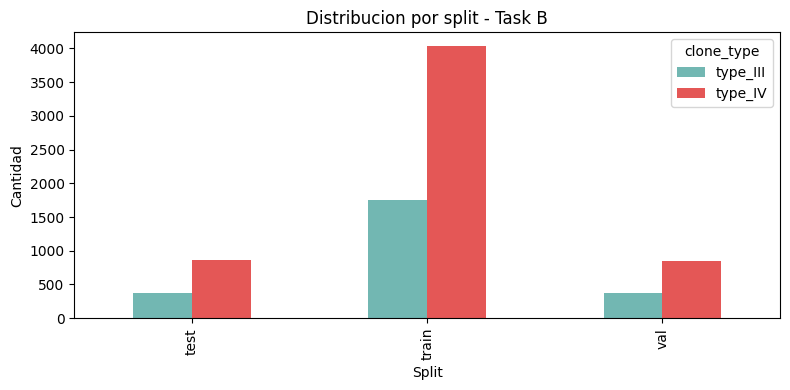

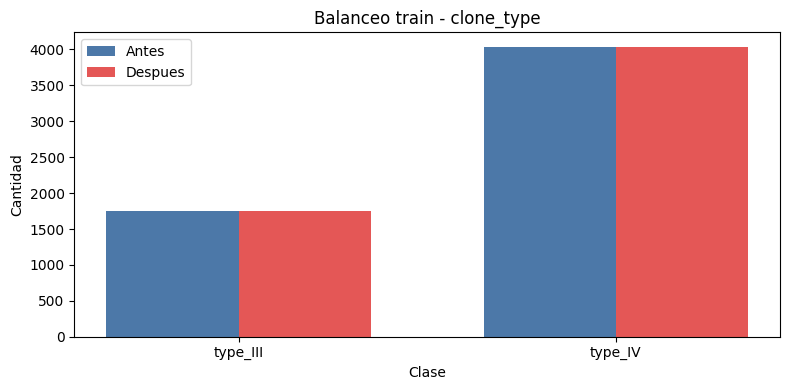

--- Informacion de balanceo ---
{'strategy': 'none', 'target_col': 'clone_type', 'rows_before': 5788, 'class_distribution_before': {'type_IV': 4037, 'type_III': 1751}, 'rows_after': 5788, 'class_distribution_after': {'type_IV': 4037, 'type_III': 1751}}
Ratio desbalance train despues de balancear: 2.3055
class_weight usado: balanced

--- Metricas VALIDACION ---
accuracy: 0.7886
f1_macro: 0.7668

--- Metricas TEST ---
accuracy: 0.7677
precision_macro: 0.7401
recall_macro: 0.7754
f1_macro: 0.7469

Reporte de clasificacion TEST:
              precision    recall  f1-score   support

    type_III       0.59      0.79      0.67       375
     type_IV       0.89      0.76      0.82       865

    accuracy                           0.77      1240
   macro avg       0.74      0.78      0.75      1240
weighted avg       0.80      0.77      0.78      1240



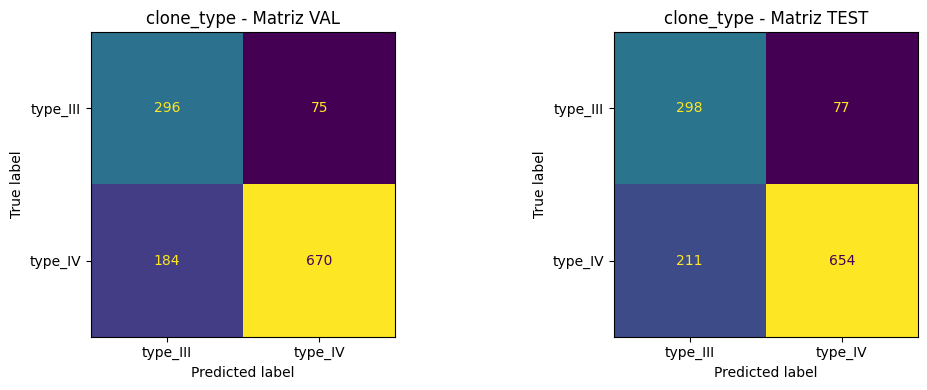

In [ ]:
# aqui graficamos el split y entrenamos task b.
conteos_split_b = datos_task_b.groupby(['split', 'clone_type']).size().unstack(fill_value=0)
conteos_split_b.plot(kind='bar', figsize=(8, 4), color=['#72B7B2', '#E45756'])
plt.title('Distribucion por split - Task B')
plt.xlabel('Split')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()

etiquetas_task_b = sorted(datos_task_b['clone_type'].unique().tolist())

resultado_task_b = entrenar_evaluar_decision_tree(
    datos_task_b,
    columna_target='clone_type',
    etiquetas=etiquetas_task_b,
    seed=SEED + 100,
    estrategia_balanceo=ESTRATEGIA_BALANCEO,
    graficar_roc=False,
)


### Resumen final


In [ ]:
# aqui juntamos los resultados principales.
resumen_final = pd.DataFrame([
    {
        'tarea': 'Task A - is_clone',
        'accuracy_val': resultado_task_a['metricas_val']['accuracy'],
        'f1_macro_val': resultado_task_a['metricas_val']['f1_macro'],
        'accuracy_test': resultado_task_a['metricas_test']['accuracy'],
        'f1_macro_test': resultado_task_a['metricas_test']['f1_macro'],
    },
    {
        'tarea': 'Task B - clone_type',
        'accuracy_val': resultado_task_b['metricas_val']['accuracy'],
        'f1_macro_val': resultado_task_b['metricas_val']['f1_macro'],
        'accuracy_test': resultado_task_b['metricas_test']['accuracy'],
        'f1_macro_test': resultado_task_b['metricas_test']['f1_macro'],
    },
])

resumen_final


,tarea,accuracy_val,f1_macro_val,accuracy_test,f1_macro_test
0,Task A - is_clone,0.894709,0.884670,0.899946,0.889604
1,Task B - clone_type,0.788571,0.766838,0.767742,0.746879
